# DATASET SELECTION

In [1]:
from google.colab import files

# This will open a file picker, choose your "IMDB Dataset.csv" from Downloads
uploaded = files.upload()

import pandas as pd

df = pd.read_csv("IMDB Dataset.csv")

print("Shape:", df.shape)
print(df.head())

df['label_id'] = df['sentiment'].map({'positive': 1, 'negative': 0})
print(df['sentiment'].value_counts())


Saving IMDB Dataset.csv to IMDB Dataset (1).csv
Shape: (50000, 2)
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


# DATASET PREPERATION

In [2]:

# Data Preparation
# - lowercase
# - remove punctuation + HTML + URLs
# - regex tokenization (avoids NLTK punkt_tab issue)
# - remove stopwords
# - lemmatize
# - split 80/20 (stratified)

# Sanity checks (expects df from previous cell)
assert 'review' in df.columns and 'sentiment' in df.columns, "df must have columns: 'review' and 'sentiment'"
if 'label_id' not in df.columns:
    df['label_id'] = df['sentiment'].map({'positive': 1, 'negative': 0})
print("Using the already-loaded DataFrame")
print("Raw shape:", df.shape)

# Minimal deps,  We only need stopwords + wordnet.
import re, string
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
tqdm.pandas()

import nltk
nltk.download('wordnet', quiet=True)
nltk.download('stopwords', quiet=True)

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Prepare cleaning tools
STOP_WORDS = set(stopwords.words('english'))
LEMM = WordNetLemmatizer()
PUNCT_TABLE = str.maketrans("", "", string.punctuation)

removed_counts = []  # store how many stopwords were removed per row (for summary)

def clean_text(text: str, print_progress=False, row_idx=None) -> str:
    """
    Lowercase, strip HTML/URLs/punctuation, regex-tokenize, remove stopwords, lemmatize.
    Uses regex tokenization to avoid NLTK punkt dependency.
    """
    if not isinstance(text, str):
        removed_counts.append(0)
        if print_progress and row_idx is not None:
            print(f"Row {row_idx}: No stopwords removed")
        return ""
    # lowercase
    s = text.lower()
    # remove HTML tags and <br> breaks
    s = re.sub(r"<br\s*/?>", " ", s)
    s = re.sub(r"<.*?>", " ", s)
    # remove URLs and @handles
    s = re.sub(r"http\S+|www\.\S+", " ", s)
    s = re.sub(r"@\w+", " ", s)
    # remove punctuation (quick pass)
    s = s.translate(PUNCT_TABLE)

    # === regex tokenization: keep a-z only (already lowercase); this also strips leftover punct
    tokens = re.findall(r"[a-z]+", s)

    # remove stopwords & short tokens
    before = len(tokens)
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) >= 2]
    removed = before - len(tokens)
    removed_counts.append(max(removed, 0))

    # per-row message if requested (demo for a few rows)
    if print_progress and row_idx is not None:
        if removed > 0:
            print(f"Row {row_idx}: Removed {removed} stopwords")
        else:
            print(f"Row {row_idx}: No stopwords removed")

    # lemmatize
    tokens = [LEMM.lemmatize(t) for t in tokens]
    return " ".join(tokens)

#  Demo messages on first 5 rows
print("\n Demo (first 5 rows): show 'Removed stopwords' / 'No stopwords removed'")
for i in range(min(5, len(df))):
    _ = clean_text(df.loc[i, 'review'], print_progress=True, row_idx=i)

# Now clean entire dataset (silent, with a progress bar)
removed_counts = []  # reset to collect counts for all rows
print("\n Cleaning full dataset ...")
df['text_clean'] = df['review'].progress_apply(clean_text)

# Drop empty rows (if any)
before_drop = len(df)
df = df[df['text_clean'].str.len() > 0].reset_index(drop=True)
after_drop = len(df)

# 5) Summary
rc = np.array(removed_counts[:after_drop]) if removed_counts else np.array([])
print("\n Cleaning summary:")
print(f"Rows before: {before_drop} | after: {after_drop} | dropped: {before_drop - after_drop}")
if rc.size:
    print(f"Total stopwords removed: {int(rc.sum())}")
    print(f"Avg stopwords removed per review: {rc.mean():.2f}")
else:
    print("No stopword removal counts recorded (edge case).")

print("\n Sample before/after:")
for i in range(2):
    print(f"\nOriginal: {df.loc[i, 'review'][:180]}...")
    print(f"Cleaned : {df.loc[i, 'text_clean'][:180]}...")

print("\nClass distribution (original labels):")
print(df['sentiment'].value_counts())

# Train/Test split 80/20 (stratified)
from sklearn.model_selection import train_test_split
X = df['text_clean']
y = df['label_id']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("\n Split sizes (80/20):")
print(f"Train: {len(X_train)}  |  Test: {len(X_test)}")

# Final dataframes for next steps
train_df = pd.DataFrame({'text_clean': X_train, 'label_id': y_train}).reset_index(drop=True)
test_df  = pd.DataFrame({'text_clean': X_test,  'label_id': y_test}).reset_index(drop=True)


print("\n Done: cleaned & split (80/20). Use train_df/test_df in feature pipelines next.")


Using the already-loaded DataFrame
Raw shape: (50000, 3)

 Demo (first 5 rows): show 'Removed stopwords' / 'No stopwords removed'
Row 0: Removed 137 stopwords
Row 1: Removed 72 stopwords
Row 2: Removed 78 stopwords
Row 3: Removed 63 stopwords
Row 4: Removed 100 stopwords

 Cleaning full dataset ...


  0%|          | 0/50000 [00:00<?, ?it/s]


 Cleaning summary:
Rows before: 50000 | after: 50000 | dropped: 0
Total stopwords removed: 5404175
Avg stopwords removed per review: 108.08

 Sample before/after:

Original: One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thin...
Cleaned : one reviewer mentioned watching oz episode youll hooked right exactly happened first thing struck oz brutality unflinching scene violence set right word go trust show faint hearted...

Original: A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism...
Cleaned : wonderful little production filming technique unassuming oldtimebbc fashion give comforting sometimes discomforting sense realism entire piece actor extremely well chosen michael s...

Class distribution (original labels):
sentiment
positive 

# FEATURE EXTRACTION

We extract features using two methods: (1) TF-IDF, which turns cleaned reviews into sparse vectors that capture term importance, and (2) pre-trained embeddings via spaCy’s en_core_web_md (300-d) to give dense, semantic representations.
We initially tried gensim Word2Vec/GloVe and Sentence-BERT, but they caused large downloads and dependency conflicts in Colab (NumPy/transformers/Torch), so spaCy vectors were chosen for stability and speed.

In [5]:

# TF-IDF FEATURE EXTRACTION (sklearn)

from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# Safety checks
assert 'text_clean' in train_df.columns, "train_df must have a 'text_clean' column"
assert 'text_clean' in test_df.columns,  "test_df must have a 'text_clean' column"
print(" Using cleaned text from 'text_clean' in train_df/test_df")

# Configure TF-IDF
# max_features: cap vocabulary size for speed/stability
# ngram_range : use unigrams + bigrams (captures short phrases)
# min_df/max_df: drop extremely rare/overly common tokens (noise)
# strip_accents: normalize accents, sublinear_tf: dampen very frequent terms
tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.90,
    strip_accents='unicode',
    sublinear_tf=True
)

print(" Fitting TF-IDF on training text and transforming train/test ...")
X_train_tfidf = tfidf_vectorizer.fit_transform(train_df['text_clean'])
X_test_tfidf  = tfidf_vectorizer.transform(test_df['text_clean'])

# Shapes & basic stats
print("TF-IDF ready.")
print(f" Train TF-IDF shape: {X_train_tfidf.shape}")   # (n_train, vocab_size)
print(f" Test  TF-IDF shape: {X_test_tfidf.shape}")    # (n_test,  vocab_size)  (same #features)

# Sparsity (how many non-zeros relative to total cells)
train_density = X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1])
test_density  = X_test_tfidf.nnz  / (X_test_tfidf.shape[0]  * X_test_tfidf.shape[1])
print(f"• Density (train): {train_density:.6f}  |  Density (test): {test_density:.6f}")

# Peek at some feature names
feature_names = np.array(tfidf_vectorizer.get_feature_names_out())
print("• Sample feature names:", feature_names[:20])


 Using cleaned text from 'text_clean' in train_df/test_df
 Fitting TF-IDF on training text and transforming train/test ...
TF-IDF ready.
 Train TF-IDF shape: (40000, 10000)
 Test  TF-IDF shape: (10000, 10000)
• Density (train): 0.009438  |  Density (test): 0.009374
• Sample feature names: ['aaron' 'abandon' 'abandoned' 'abbott' 'abc' 'ability' 'able' 'able get'
 'able see' 'aboard' 'abomination' 'abortion' 'abound' 'abraham' 'abrupt'
 'abruptly' 'absence' 'absent' 'absolute' 'absolutely']


In [6]:
# Pretrained Embeddings via spaCy (300-d) — stable path
# Assumes: train_df['text_clean'], test_df['text_clean'] already exist

!pip -q install spacy==3.7.5
!pip -q install https://github.com/explosion/spacy-models/releases/download/en_core_web_md-3.7.1/en_core_web_md-3.7.1-py3-none-any.whl

import numpy as np
import spacy
from tqdm.auto import tqdm
tqdm.pandas()

# Load the model with pretrained vectors only (no parser/ner/tagger needed)
nlp = spacy.load("en_core_web_md", exclude=["parser","ner","tagger","attribute_ruler","lemmatizer"])

def encode_with_spacy(texts, batch_size=512):
    """
    Mean-pool spaCy's pretrained word vectors to get 1 vector per review.
    Output: float32 array of shape (n_samples, 300)
    """
    vecs = []
    for doc in tqdm(nlp.pipe(texts.tolist(), batch_size=batch_size), total=len(texts)):
        vecs.append(doc.vector)  # 300-d vector
    return np.vstack(vecs).astype(np.float32)

print(" Encoding train reviews with spaCy vectors…")
X_train_embed = encode_with_spacy(train_df["text_clean"])
print(" Encoding test reviews with spaCy vectors…")
X_test_embed  = encode_with_spacy(test_df["text_clean"])

print("Pretrained embeddings ready.")
print("  • Train spaCy shape:", X_train_embed.shape)
print("  • Test  spaCy shape:", X_test_embed.shape)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 MB 22.3 MB/s eta 0:00:00
 Encoding train reviews with spaCy vectors…


  0%|          | 0/40000 [00:00<?, ?it/s]

 Encoding test reviews with spaCy vectors…


  0%|          | 0/10000 [00:00<?, ?it/s]

Pretrained embeddings ready.
  • Train spaCy shape: (40000, 300)
  • Test  spaCy shape: (10000, 300)


# MODEL TRAINING

In [16]:


#   TF-IDF → (LogisticRegression, MultinomialNB)
#   EMBED  → (LogisticRegression, RandomForest)
#   Metrics: Accuracy, Precision_macro, Recall_macro, F1_macro, secs

QUICK = True
TRAIN_SUB = 10_000
TEST_SUB  = 5_000
RF_TREES  = 200 if QUICK else 400
LR_ITERS_SPARSE = 200 if QUICK else 300   # TF-IDF LR iters
LR_ITERS_EMBED  = 200 if QUICK else 500   # Embedding LR iters


import time
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from IPython.display import display

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

#  If embeddings were named *_spacy, alias them
if 'X_train_embed' not in globals() and 'X_train_embed_spacy' in globals():
    X_train_embed = X_train_embed_spacy
    X_test_embed  = X_test_embed_spacy

# Safety checks
needed = ["X_train_tfidf","X_test_tfidf","X_train_embed","X_test_embed","y_train","y_test"]
missing = [v for v in needed if v not in globals()]
assert not missing, f"Missing: {missing}. Build TF-IDF & embeddings first."

# Ensure labels are arrays for fancy indexing
y_train_arr = y_train.values if hasattr(y_train, "values") else np.asarray(y_train)
y_test_arr  = y_test.values  if hasattr(y_test,  "values")  else np.asarray(y_test)

#  subsample for speed
if QUICK:
    tr_idx = rng.choice(X_train_tfidf.shape[0], size=min(TRAIN_SUB, X_train_tfidf.shape[0]), replace=False)
    te_idx = rng.choice(X_test_tfidf.shape[0],  size=min(TEST_SUB,  X_test_tfidf.shape[0]),  replace=False)

    Xtr_tfidf, Xte_tfidf = X_train_tfidf[tr_idx], X_test_tfidf[te_idx]
    Xtr_emb,   Xte_emb   = X_train_embed[tr_idx], X_test_embed[te_idx]
    ytr, yte             = y_train_arr[tr_idx],   y_test_arr[te_idx]

    print(f"  Train: {Xtr_tfidf.shape[0]}  |  Test: {Xte_tfidf.shape[0]}")
else:
    Xtr_tfidf, Xte_tfidf = X_train_tfidf, X_test_tfidf
    Xtr_emb,   Xte_emb   = X_train_embed, X_test_embed
    ytr, yte             = y_train_arr,   y_test_arr
    print(f"Full run → Train: {Xtr_tfidf.shape[0]}  |  Test: {Xte_tfidf.shape[0]}")

# Helper (TRAINING happens at model.fit)
def fit_eval(name, model, Xtr, ytr, Xte, yte, verbose=False):
    t0 = time.time()
    model.fit(Xtr, ytr)                # TRAINING happens here
    yhat = model.predict(Xte)
    secs = time.time() - t0

    acc = accuracy_score(yte, yhat)
    prec, rec, f1, _ = precision_recall_fscore_support(yte, yhat, average="macro", zero_division=0)
    if verbose:
        print(f"\n[{name}] Acc {acc:.4f} | Prec(m) {prec:.4f} | Rec(m) {rec:.4f} | F1(m) {f1:.4f} | {secs:.1f}s")
        print(classification_report(yte, yhat, digits=4))
    return {"model": name, "accuracy": acc, "precision_macro": prec, "recall_macro": rec, "f1_macro": f1, "secs": secs}, yhat

results = []
trained_models = {}
preds = {}


print(" Training on TF-IDF...")
tfidf_logreg = LogisticRegression(solver="liblinear", max_iter=LR_ITERS_SPARSE,
                                  class_weight="balanced", random_state=RANDOM_SEED)
tfidf_mnb    = MultinomialNB()  # TF-IDF is non-negative → suitable

res, yhat = fit_eval("TFIDF + LogisticRegression", tfidf_logreg, Xtr_tfidf, ytr, Xte_tfidf, yte)
results.append(res); trained_models[res["model"]] = tfidf_logreg; preds[res["model"]] = yhat

res, yhat = fit_eval("TFIDF + MultinomialNB", tfidf_mnb, Xtr_tfidf, ytr, Xte_tfidf, yte)
results.append(res); trained_models[res["model"]] = tfidf_mnb;    preds[res["model"]] = yhat


print("\n Training on Embeddings...")
emb_logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(solver="lbfgs", max_iter=LR_ITERS_EMBED,
                               class_weight="balanced", random_state=RANDOM_SEED))
])
emb_rf = RandomForestClassifier(n_estimators=RF_TREES, n_jobs=-1, random_state=RANDOM_SEED,
                                class_weight="balanced_subsample")

res, yhat = fit_eval("EMBED + LogisticRegression", emb_logreg, Xtr_emb, ytr, Xte_emb, yte)
results.append(res); trained_models[res["model"]] = emb_logreg;  preds[res["model"]] = yhat

res, yhat = fit_eval("EMBED + RandomForest", emb_rf, Xtr_emb, ytr, Xte_emb, yte)
results.append(res); trained_models[res["model"]] = emb_rf;      preds[res["model"]] = yhat

# =Build df_results for display
df_results = (
    pd.DataFrame(results)
      .sort_values(["f1_macro","accuracy"], ascending=False)
      .reset_index(drop=True)
)

##PRETTY TABLE
cols = ["model","accuracy","precision_macro","recall_macro","f1_macro","secs"]
out = (
    df_results[cols]
      .rename(columns={
          "precision_macro":"precision",
          "recall_macro":"recall",
          "f1_macro":"f1",
          "secs":"time_sec"
      })
      .round({"accuracy":4,"precision":4,"recall":4,"f1":4,"time_sec":1})
)

def zebra_rows(row):
    return ['background-color: #f9fafb'] * len(row) if row.name % 2 == 0 else ['background-color: #ffffff'] * len(row)

styler = out.style.set_caption("Classifier Comparison (TF-IDF vs. Pretrained Embeddings)")
# Hide index (cross-version)
if hasattr(styler, "hide"):
    styler = styler.hide(axis="index")
elif hasattr(styler, "hide_index"):
    styler = styler.hide_index()

styler = (
    styler
    .apply(zebra_rows, axis=1)
    .set_table_styles([
        {'selector': 'table',   'props': 'border-collapse: separate; border-spacing:0; width:100%; background:#ffffff; color:#111; font-size:14px;'},
        {'selector': 'th',      'props': 'background:#0D47A1; color:#fff; text-align:center; padding:8px; border:1px solid #e5e7eb;'},
        {'selector': 'td',      'props': 'padding:8px; border:1px solid #e5e7eb; text-align:center; color:#111;'},
        {'selector': 'caption', 'props': 'caption-side: top; font-size:16px; font-weight:700; color:#111; padding:6px;'},
    ])
    .bar(subset=["accuracy","precision","recall","f1"], color="#C8E6C9")
)

try:
    display(styler)
except Exception as e:
    print("Styled display failed, falling back to plain table:", e)
    print(out.to_string(index=False))

# Legends
print("\nLEGENDS")
print("• TF-IDF: Sparse text representation weighting unigrams/bigrams by TF×IDF to emphasize distinctive terms.")
print("• MultinomialNB: Naïve Bayes variant suited to count-like features (TF/TF-IDF); very fast for text.")
print("• Logistic Regression: Strong linear baseline; works well on both sparse TF-IDF and dense embeddings.")
print(f"• Random Forest: Tree ensemble on dense features (embeddings). Trees={RF_TREES} {'(reduced for speed)' if QUICK else ''}.")
print(f"• QUICK mode: Train={Xtr_tfidf.shape[0]} / Test={Xte_tfidf.shape[0]}; toggle QUICK=False for the full dataset.")



  Train: 10000  |  Test: 5000
 Training on TF-IDF...

 Training on Embeddings...


model,accuracy,precision,recall,f1,time_sec
TFIDF + LogisticRegression,0.880800,0.881100,0.880700,0.880700,0.200000
TFIDF + MultinomialNB,0.857000,0.857300,0.856900,0.856900,0.000000
EMBED + LogisticRegression,0.825000,0.825000,0.825000,0.825000,1.400000
EMBED + RandomForest,0.758200,0.758200,0.758200,0.758200,44.500000



LEGENDS
• TF-IDF: Sparse text representation weighting unigrams/bigrams by TF×IDF to emphasize distinctive terms.
• MultinomialNB: Naïve Bayes variant suited to count-like features (TF/TF-IDF); very fast for text.
• Logistic Regression: Strong linear baseline; works well on both sparse TF-IDF and dense embeddings.
• Random Forest: Tree ensemble on dense features (embeddings). Trees=200 (reduced for speed).
• QUICK mode: Train=10000 / Test=5000; toggle QUICK=False for the full dataset.


# MODEL EVALUATION AND COMPARRISON

model,accuracy,precision,recall,f1,time_sec
TFIDF + LogisticRegression,0.880800,0.881100,0.880700,0.880700,0.200000
TFIDF + MultinomialNB,0.857000,0.857300,0.856900,0.856900,0.000000
EMBED + LogisticRegression,0.825000,0.825000,0.825000,0.825000,1.400000
EMBED + RandomForest,0.758200,0.758200,0.758200,0.758200,44.500000


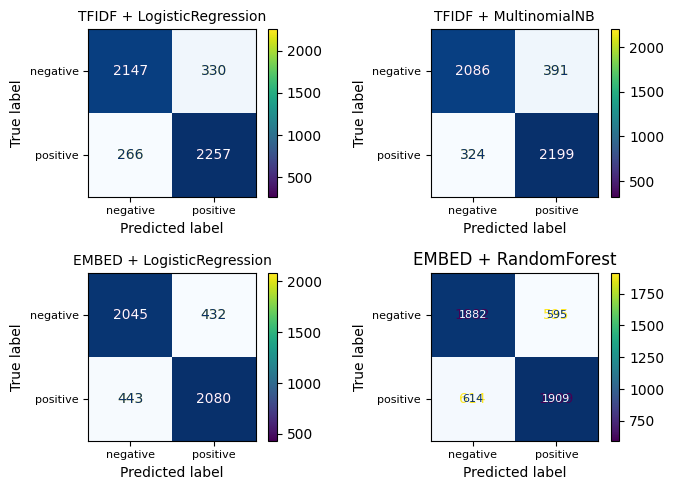


TFIDF + LogisticRegression — classification report
              precision    recall  f1-score   support

    negative     0.8898    0.8668    0.8781      2477
    positive     0.8724    0.8946    0.8834      2523

    accuracy                         0.8808      5000
   macro avg     0.8811    0.8807    0.8807      5000
weighted avg     0.8810    0.8808    0.8808      5000


TFIDF + MultinomialNB — classification report
              precision    recall  f1-score   support

    negative     0.8656    0.8421    0.8537      2477
    positive     0.8490    0.8716    0.8602      2523

    accuracy                         0.8570      5000
   macro avg     0.8573    0.8569    0.8569      5000
weighted avg     0.8572    0.8570    0.8570      5000


EMBED + LogisticRegression — classification report
              precision    recall  f1-score   support

    negative     0.8219    0.8256    0.8238      2477
    positive     0.8280    0.8244    0.8262      2523

    accuracy                   

In [19]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

#  Sanity checks
for v in ["df_results", "preds"]:
    assert v in globals(), f"Missing `{v}`. Run the training cell first."
y_true = yte if 'yte' in globals() else (y_test.values if hasattr(y_test, "values") else np.asarray(y_test))

#  summary table
cols = ["model","accuracy","precision_macro","recall_macro","f1_macro","secs"]
out = (
    df_results[cols]
      .rename(columns={
          "precision_macro":"precision",
          "recall_macro":"recall",
          "f1_macro":"f1",
          "secs":"time_sec"
      })
      .round({"accuracy":4,"precision":4,"recall":4,"f1":4,"time_sec":1})
)

def zebra_rows(row):
    return ['background-color: #f9fafb'] * len(row) if row.name % 2 == 0 else ['background-color: #ffffff'] * len(row)

styler = out.style.set_caption("Model Comparison (Accuracy / Precision / Recall / F1 — macro)")
# Hide index across pandas versions
if hasattr(styler, "hide"): styler = styler.hide(axis="index")
elif hasattr(styler, "hide_index"): styler = styler.hide_index()
styler = (
    styler
    .apply(zebra_rows, axis=1)
    .set_table_styles([
        {'selector': 'table',   'props': 'border-collapse: separate; border-spacing:0; width:100%; background:#ffffff; color:#111; font-size:14px;'},
        {'selector': 'th',      'props': 'background:#0D47A1; color:#fff; text-align:center; padding:8px; border:1px solid #e5e7eb;'},
        {'selector': 'td',      'props': 'padding:8px; border:1px solid #e5e7eb; text-align:center; color:#111;'},
        {'selector': 'caption', 'props': 'caption-side: top; font-size:16px; font-weight:700; color:#111; padding:6px;'},
    ])
)
display(styler)

#  Confusion matrices (using saved predictions) ----------
labels = [0, 1]                       # assuming 0=negative, 1=positive
display_labels = ['negative','positive']

names = list(preds.keys())
n = len(names)
rows = (n + 1) // 2
fig, axes = plt.subplots(rows, 2, figsize=(7, 2.5*rows))
axes = np.array(axes).reshape(-1)     # flatten in case of single row

for ax, name in zip(axes, names):
    y_hat = preds[name]
    cm = confusion_matrix(y_true, y_hat, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
    disp.plot(ax=ax, values_format='d')
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
    disp.plot(ax=ax, values_format='d', cmap='Blues', colorbar=False)

    ax.set_title(name, fontsize=10)              # smaller title
    ax.tick_params(labelsize=8)                  # smaller ticks
for t in disp.text_.ravel():                 # smaller cell numbers
    t.set_fontsize(8)

    ax.set_title(name)
    # make it consistent with white bg
    ax.figure.set_facecolor('white')
    ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")

# hide any extra axes if models < grid slots
for k in range(len(names), len(axes)):
    axes[k].axis('off')

plt.tight_layout()
plt.show()

# Per-class reports
for name in names:
    print(f"\n{name} — classification report")
    print(classification_report(y_true, preds[name], target_names=display_labels, digits=4))


In [20]:
import joblib
joblib.dump(tfidf_vectorizer, "/content/tfidf_vectorizer.joblib")
joblib.dump(trained_models["TFIDF + LogisticRegression"], "/content/model_tfidf_logreg.joblib")
print("Saved:", "/content/tfidf_vectorizer.joblib", "/content/model_tfidf_logreg.joblib")


Saved: /content/tfidf_vectorizer.joblib /content/model_tfidf_logreg.joblib


In [21]:
from google.colab import files
files.download('/content/tfidf_vectorizer.joblib')
files.download('/content/model_tfidf_logreg.joblib')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>